In [114]:
#import user modules
#--- MATPLOTLIB
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.markers import MarkerStyle
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

import sys
my_path = "../../../QHamSolver/Python/"
if my_path not in sys.path:
    sys.path.append(my_path)
 
for place in sys.path: 
    print(place)

from fit_funcs import *
import costfun.costfun as cost
import utils.figures as fig_help
import utils.tools as tools
from RandomMatrixTheory import goe, gue
from tools import *
import entropy as ent

import importlib as imp
def reload_modules():
    imp.reload(cost)
    imp.reload(fig_help)

from mpl_toolkits.axes_grid1 import make_axes_locatable

import itertools
matplotlib.rcParams['mathtext.fontset'] = 'cm'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
latex_engine = 'xelatex'
latex_elements = {'preamble':r'\usepackage{physics}'}
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = r'\usepackage{physics}\usepackage{xcolor}\usepackage{amsmath}\usepackage{amsfonts}'


%matplotlib inline
colors_ls = (list(mcolors.TABLEAU_COLORS)[:200])
colors_ls_cyc = itertools.cycle(colors_ls)

markers_ls = ['o','s','v', 'D', '<', 'X', '^', '*', '+']
markers = itertools.cycle(markers_ls)

#--- NUMERICAL LIBS
import numpy as np
import itertools
import math
import random
from cmath import nan
import h5py   


# SCIPY LIBS
import scipy.stats as statistics
from scipy.special import binom
from scipy.special import erfinv
from scipy.special import digamma
from scipy.special import polygamma
from scipy.special import gamma as Gamma
from scipy.special import lambertw
from scipy.special import dawsn as dawson
from scipy.optimize import curve_fit as fit
from scipy.signal import savgol_filter
from scipy import integrate
from scipy import fft
 
# OTHER
import warnings
warnings.filterwarnings('ignore')
from joblib import Parallel, delayed
import copy
import os
from os import sep as kPSep
from os.path import exists


def base_dir(BC = 0):
    """
    Base directory for input model for d-dimension
    """
    dirx = f"../results/" + (f"PBC/" if BC else f"OBC/")
    return dirx

%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}

/Users/rafal.swietek/Projects/CODES/LGT_Project/BosonicSpinfullQLM/Jupyter_Notebook
/Users/rafal.swietek/opt/anaconda3/lib/python39.zip
/Users/rafal.swietek/opt/anaconda3/lib/python3.9
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/lib-dynload

/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/aeosa
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/locket-0.2.1-py3.9.egg
/Users/rafal.swietek/opt/anaconda3/lib/python3.9/site-packages/IPython/extensions
/Users/rafal.swietek/.ipython
../../../QHamSolver/Python/


No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


../results/PBC/NeelOrder/_Lx=3,Ly=3,Nu=4,Nd=5,tau=1,m=-1.hdf5
../results/PBC/NeelOrder/_Lx=3,Ly=3,Nu=4,Nd=5,tau=1,m=0.hdf5
../results/PBC/NeelOrder/_Lx=3,Ly=3,Nu=4,Nd=5,tau=1,m=1.hdf5


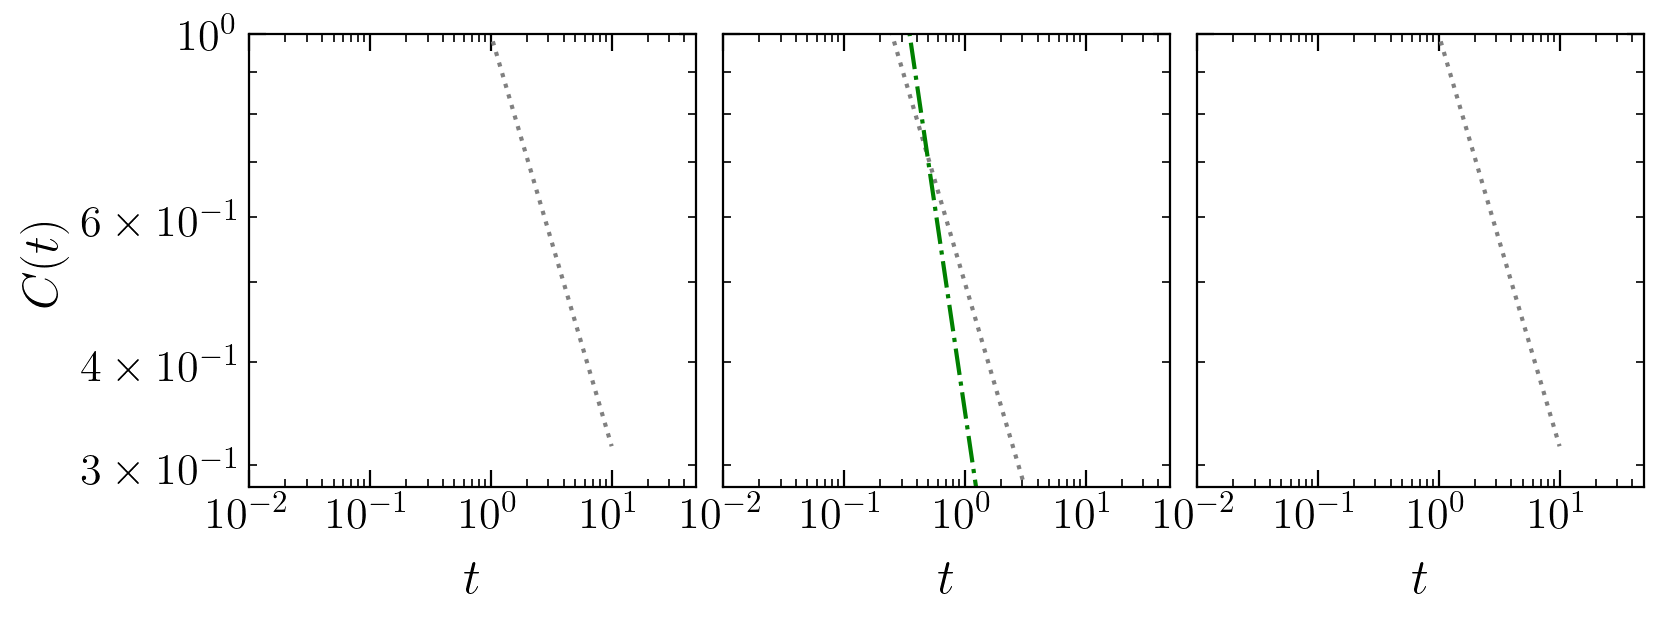

In [57]:
Lx = 3
Ly = 3
Nu = 4
Nd = 5
tau = 1
mass = 0
BC = 1 #PBC: BC=1

V = Lx*Ly

if Nu < 0:
    Nu = Lx * Ly - Nd
if Nd < 0:
    Nd = Lx * Ly - Nu

fig, ax = plt.subplots( nrows=1, ncols=3, figsize=(9,3), dpi = 200, sharey=True)
mas = [-1, 0.0, 1]

for iim, mass in enumerate(mas):
    axis = ax[iim]
    name = base_dir(BC) + "NeelOrder/" + info(Lx, Ly, Nu, Nd, tau, mass, '.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            times = np.array(file.get('times'))[0]
            aurocorr = np.array(file.get('Autocorrelation_spinup'))[0]
            axis.plot(times, aurocorr / aurocorr[0], color='red', ls='-', label=r"$\hat{n}_\uparrow$")
            aurocorr = np.array(file.get('Autocorrelation_spindown'))[0]
            axis.plot(times, aurocorr / aurocorr[0], color='k', ls='--', label=r"$\hat{n}_\downarrow$")
    else:
        print(name)
        
    fig_help.set_plot_elements(axis, ylabel=r"$C(t)$" if iim ==0 else "", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
    t = np.logspace(-1, 1, 1000)
    if iim==1:
        axis.plot(t, 0.5/t**0.5, ls=':', color='gray')
        axis.plot(t, 0.35/t, ls='-.', color='green')
    else:
        axis.plot(t, 1/t**0.5, ls=':', color='gray')
    axis.set_xlim(1e-2, 5e1)
    axis.set_ylim(None, 1)
    
fig.subplots_adjust(wspace = 0.06, hspace=0.06)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.


../results/PBC/NeelOrder/_Lx=3,Ly=3,Nu=4,Nd=5,tau=1,m=-1.hdf5
../results/PBC/NeelOrder/_Lx=3,Ly=3,Nu=4,Nd=5,tau=1,m=0.hdf5
../results/PBC/NeelOrder/_Lx=3,Ly=3,Nu=4,Nd=5,tau=1,m=1.hdf5


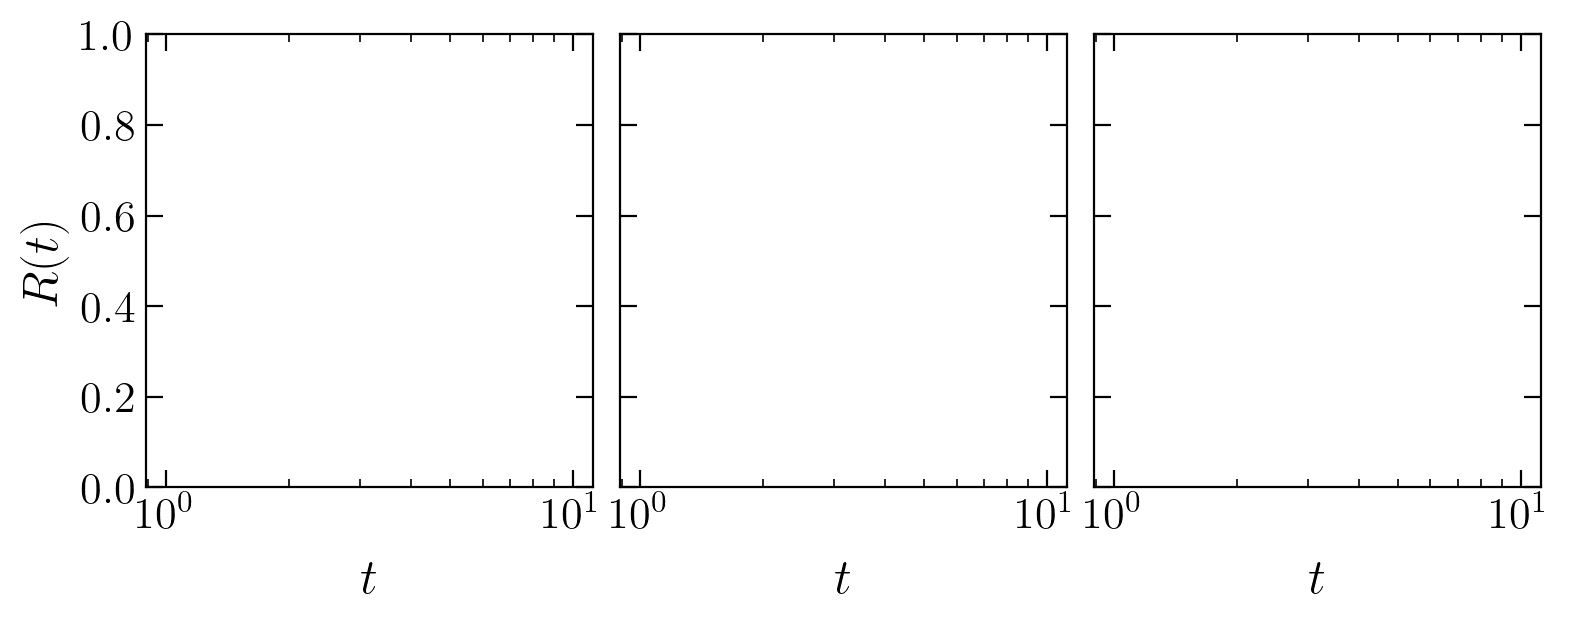

In [58]:
Lx = 3
Ly = 3
Nu = 4
Nd = 5
tau = 1
mass = 0
BC = 1 #PBC: BC=1

V = Lx*Ly

if Nu < 0:
    Nu = Lx * Ly - Nd
if Nd < 0:
    Nd = Lx * Ly - Nu

fig, ax = plt.subplots( nrows=1, ncols=3, figsize=(9,3), dpi = 200, sharey=True)
mas = [-1, 0.0, 1]

for iim, mass in enumerate(mas):
    axis = ax[iim]
    name = base_dir(BC) + "NeelOrder/" + info(Lx, Ly, Nu, Nd, tau, mass, '.hdf5')
    if exists(name):
        with h5py.File(name, "r") as file:
            times = np.array(file.get('times'))[0]
            aurocorr = np.array(file.get('Neel/return_probability'))[0]
            axis.plot(times, aurocorr, color='red', ls='-', label=r"Neel")
            aurocorr = np.array(file.get('DomainWall/return_probability'))[0]
            axis.plot(times, aurocorr, color='k', ls='--', label=r"DW")
    else:
        print(name)
        
    fig_help.set_plot_elements(axis, ylabel=r"$R(t)$" if iim ==0 else "", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='linear')
    # t = np.logspace(-1, 1, 1000)
    # if iim==1:
    #     axis.plot(t, 0.5/t**0.5, ls=':', color='gray')
    #     axis.plot(t, 0.35/t, ls='-.', color='green')
    # else:
    #     axis.plot(t, 1/t**0.5, ls=':', color='gray')
    # axis.set_xlim(1e-2, 5e1)
    axis.set_ylim(None, 1)
    
fig.subplots_adjust(wspace = 0.06, hspace=0.06)

No handles with labels found to put in legend.
No handles with labels found to put in legend.


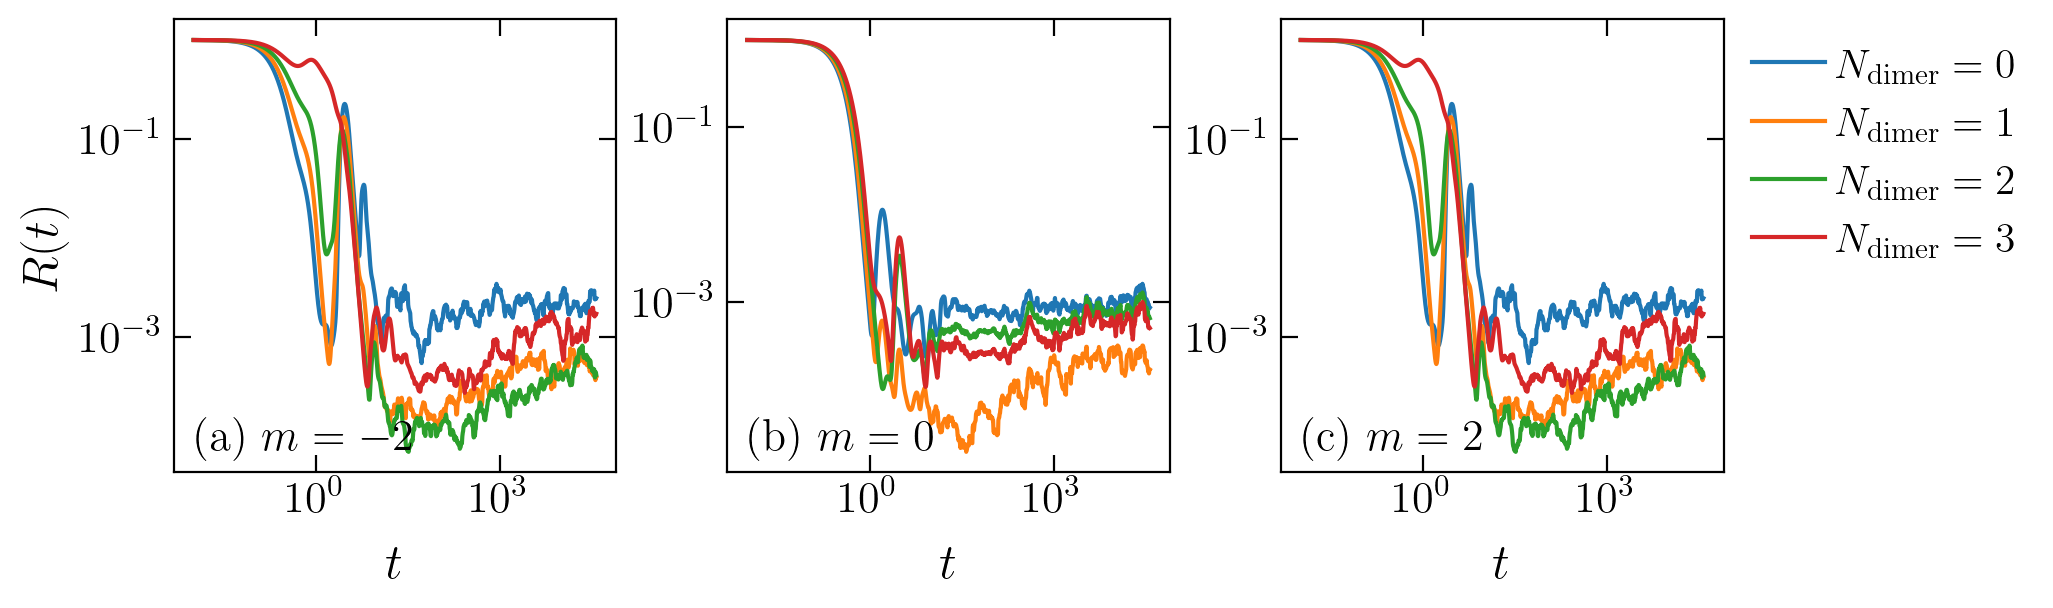

In [59]:
from matplotlib.patches import Rectangle
from matplotlib import cm

fig, axis = plt.subplots( nrows=1, ncols=3, figsize=(10, 3), dpi = 200)#, sharex=False, sharey='row')
# figaaa, axisaaa = plt.subplots( nrows=1, ncols=1, figsize=(4, 4), dpi = 200)

Lx = 5
Ly = 5
Nu = -1
mass = -2
tau = 1
BC = 0


Nd = 3
Nu = -1 
if Nu < 0: Nu = Lx * Ly - Nd 

for iim, mass in enumerate([-2, 0, 2]):
    name = base_dir(BC) + "DimerDecay/" + info(Lx, Ly, Nu, Nd, tau, mass,',kx=0,ky=0,px=1,py=1,pd=1.hdf5' if BC else ',px=1,py=1,pd=1.hdf5')
    if exists(name): 
        with h5py.File(name, "r") as file: 
            times = np.abs(np.array(file.get('times')))[0][:-10]
            for Ndimer in range(0, Nd+1):
                DimerDecay = np.array(file.get('Ndimer=%d/return_probability'%Ndimer))[0] 
                # DimerDecay = np.array(file.get('Ndimer=%d/DimerNumber(t)'%Ndimer))[0] 
                DimerDecay = tools.remove_fluctuations(DimerDecay, bucket_size=20)[:-10]
                axis[iim].plot(times, DimerDecay / DimerDecay[0]**1, label = r"$N_{\rm dimer}=%d$"%Ndimer if iim == 2 else "")  
    else: 
        print(name)
    fig_help.set_plot_elements(axis[iim], ylabel=r"$R(t)$" if iim == 0 else "", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
axis[0].annotate(r"(a) $m=-2$", fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction', color='k')
axis[1].annotate(r"(b) $m=0$", fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction', color='k')
axis[2].annotate(r"(c) $m=2$", fontsize=16, xy=(0.05, 0.05), xycoords='axes fraction', color='k')
fig_help.set_legend(axis[2], fontsize=15, loc='upper left', anchor=(0.98, 1.02))

fig.subplots_adjust(wspace = 0.25, hspace=0.16)

In [74]:
from sympy import Matrix, var
from sympy.physics.quantum import TensorProduct as tens
from sympy.physics.quantum.dagger import Dagger as dag
from sympy import Symbol, simplify, exp, log, pi
from sympy import Sum
from sympy import I
from sympy import solve
from sympy import zeros
from sympy import Rational
import sympy


In [75]:

x = Symbol('tau', real=True)
m = Symbol('m', real=True)


sig_plus    = Matrix([[0, 1], [0, 0]])
sig_minu    = Matrix([[0, 0], [1, 0]])
no_dimer    = Matrix([[1, 0], [0, 0]])
e = Matrix([[1, 0], [0, 1]])

Mass = tens(no_dimer, 2*m * tens(e, e))
hops = Matrix([[-x, -x, 0, 0], [0, -x, -x, 0], [0,0,-x, -x], [-x, 0, 0, -x]])

H = Mass + tens(sig_minu, hops) + tens(sig_plus, dag(hops))

V, D = H.diagonalize()
# D
# V #.subs(m, 0)
D

Matrix([
[0,   0,                         0,                         0,                         0,                         0,                         0,                         0],
[0, 2*m,                         0,                         0,                         0,                         0,                         0,                         0],
[0,   0, m - sqrt(m**2 + 2*tau**2),                         0,                         0,                         0,                         0,                         0],
[0,   0,                         0, m - sqrt(m**2 + 2*tau**2),                         0,                         0,                         0,                         0],
[0,   0,                         0,                         0, m + sqrt(m**2 + 2*tau**2),                         0,                         0,                         0],
[0,   0,                         0,                         0,                         0, m + sqrt(m**2 + 2*tau**2),               

In [76]:
V

Matrix([
[ 0, -1,  (m - sqrt(m**2 + 2*tau**2))/(2*tau), (-m + sqrt(m**2 + 2*tau**2))/(2*tau),  (m + sqrt(m**2 + 2*tau**2))/(2*tau), -(m + sqrt(m**2 + 2*tau**2))/(2*tau), (-m + sqrt(m**2 + 4*tau**2))/(2*tau), -(m + sqrt(m**2 + 4*tau**2))/(2*tau)],
[ 0,  1,  (m - sqrt(m**2 + 2*tau**2))/(2*tau),  (m - sqrt(m**2 + 2*tau**2))/(2*tau),  (m + sqrt(m**2 + 2*tau**2))/(2*tau),  (m + sqrt(m**2 + 2*tau**2))/(2*tau), (-m + sqrt(m**2 + 4*tau**2))/(2*tau), -(m + sqrt(m**2 + 4*tau**2))/(2*tau)],
[ 0, -1, (-m + sqrt(m**2 + 2*tau**2))/(2*tau),  (m - sqrt(m**2 + 2*tau**2))/(2*tau), -(m + sqrt(m**2 + 2*tau**2))/(2*tau),  (m + sqrt(m**2 + 2*tau**2))/(2*tau), (-m + sqrt(m**2 + 4*tau**2))/(2*tau), -(m + sqrt(m**2 + 4*tau**2))/(2*tau)],
[ 0,  1, (-m + sqrt(m**2 + 2*tau**2))/(2*tau), (-m + sqrt(m**2 + 2*tau**2))/(2*tau), -(m + sqrt(m**2 + 2*tau**2))/(2*tau), -(m + sqrt(m**2 + 2*tau**2))/(2*tau), (-m + sqrt(m**2 + 4*tau**2))/(2*tau), -(m + sqrt(m**2 + 4*tau**2))/(2*tau)],
[-1,  0,                               

In [112]:
from sympy import zeros

x = Symbol('tau', real=True)
m = Symbol('m', real=True)

Lx = 2
Ly = 2
N = 16

A = zeros(N, N)

for i in range(N):
    if i < 6: A[i,i] = m
    elif i >= 6 and i < 14: A[i,i] = m / 2
    
A[0, 7] = -x;   A[0, 10] = -x;
A[1, 6] = -x;   A[1, 12] = -x;
A[2, 6] = -x;   A[2, 7] = -x;  A[2, 11] = -x;   A[2, 13] = -x;
A[3, 8] = -x;   A[3, 9] = -x;  A[3, 10] = -x;   A[3, 12] = -x;
A[4, 8] = -x;   A[4, 13] = -x;  A[5, 9] = -x;   A[5, 11] = -x;
A[6, 15] = -x;
A[7, 14] = -x;
A[8, 15] = -x;
A[9, 14] = -x;
A[10, 14] = -x;
A[11, 14] = -x;
A[12, 15] = -x;
A[13, 15] = -x;
A[2,2] = 2*m
A[3,3] = 2*m
A = A + dag(A)

# V2, D2 = A.diagonalize()
A
# A.nullspace()
# from sympy import Matrix, symbols, linsolve

# psi = Matrix(symbols(f'psi0:{N}'))

# eqs = list(A * psi)

# sol = linsolve(eqs, psi)
# print(sol)
# A = A.subs({m: 1, x: 1})  # or whatever parameters you need
# V2, D2 = A.diagonalize()
# D2

Matrix([
[ 2*m,    0,    0,    0,    0,    0,    0, -tau,    0,    0, -tau,    0,    0,    0,    0,    0],
[   0,  2*m,    0,    0,    0,    0, -tau,    0,    0,    0,    0,    0, -tau,    0,    0,    0],
[   0,    0,  4*m,    0,    0,    0, -tau, -tau,    0,    0,    0, -tau,    0, -tau,    0,    0],
[   0,    0,    0,  4*m,    0,    0,    0,    0, -tau, -tau, -tau,    0, -tau,    0,    0,    0],
[   0,    0,    0,    0,  2*m,    0,    0,    0, -tau,    0,    0,    0,    0, -tau,    0,    0],
[   0,    0,    0,    0,    0,  2*m,    0,    0,    0, -tau,    0, -tau,    0,    0,    0,    0],
[   0, -tau, -tau,    0,    0,    0,    m,    0,    0,    0,    0,    0,    0,    0,    0, -tau],
[-tau,    0, -tau,    0,    0,    0,    0,    m,    0,    0,    0,    0,    0,    0, -tau,    0],
[   0,    0,    0, -tau, -tau,    0,    0,    0,    m,    0,    0,    0,    0,    0,    0, -tau],
[   0,    0,    0, -tau,    0, -tau,    0,    0,    0,    m,    0,    0,    0,    0, -tau,    0],
[-tau,    0

In [113]:
A = A.subs({m: 1, x: 1})  # or whatever parameters you need
V2, D2 = A.diagonalize()
D2
# zero_modes = A.nullspace()
# print( len(zero_modes) )
# Matrix.hstack(*zero_modes)
# Matrix(zero_modes)

KeyboardInterrupt: 

In [ ]:
D2

Num 0 modes:  38
Dimer band 0.5313314921370179
Dangling states 0.10238322458889562
Corner bands 0.0601175379810621
Edge bands 0.3156083083634758
Monomer bands 0.5241433551221226


No handles with labels found to put in legend.
No handles with labels found to put in legend.


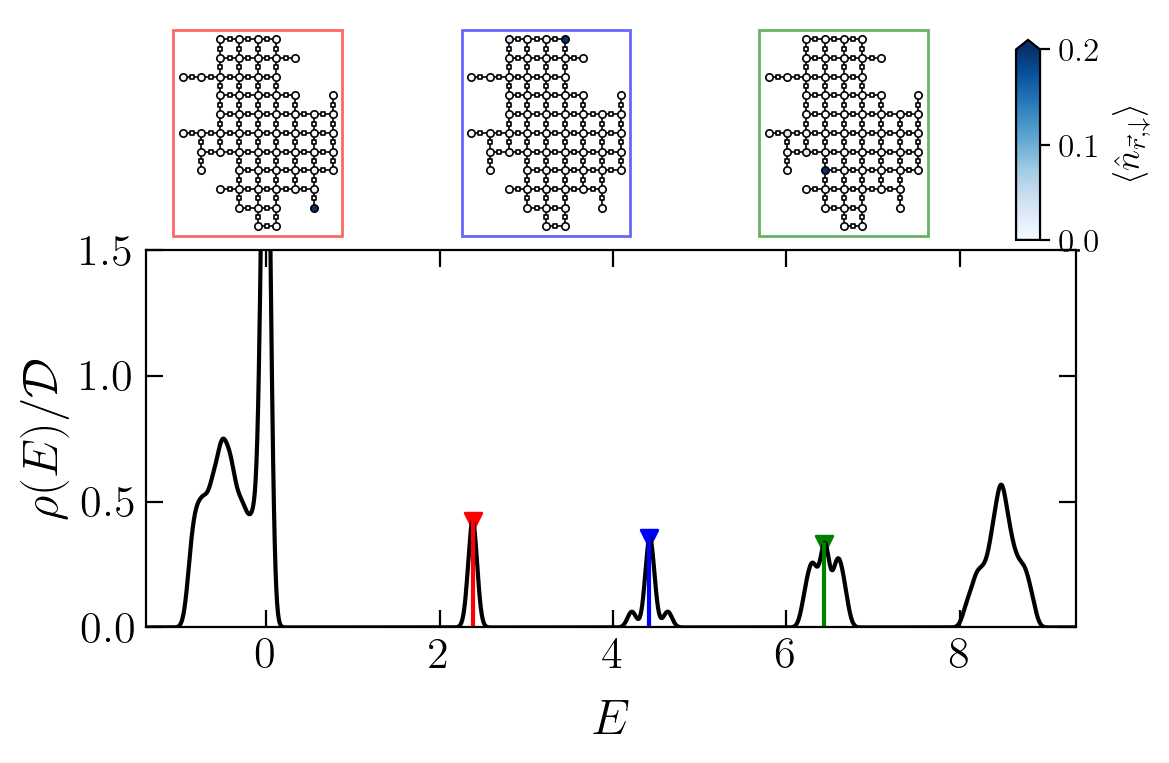

In [355]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

L = 64
tau = 1
mass = 2
BC = 0 #PBC: BC=1


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(6,2.5), dpi = 200, sharex=True)

# axis2 = axis.twinx()

arr = [tau, mass]
names = ['tau', 'm']
infoLieb = "_L=%d"%(L)
for i, var in enumerate(arr):
    # print(names[i], var)
    n = order_of_magnitude( np.abs(var) )
    if np.abs(var) < 1e-15:
        infoLieb += str(",%s=0"%(names[i]))
    elif var < 0:
        infoLieb += str(",%s=-{:.%df}"%(names[i], n)).format(round(np.abs(var), n))     
    else:
        infoLieb += str(",%s={:.%df}"%(names[i], n)).format(round(np.abs(var), n))

name = "../results/LiebLatticeRandomShape/realization=0/" + infoLieb + ".hdf5"
if exists(name):
    with h5py.File(name, "r") as file:
        E = np.array(file.get('E'))[0]
        Ezero = E[np.abs(E) < 1e-12]
        print("Num 0 modes: ", Ezero.size)
        E = np.round(E, 14)
        _, indices, counts = np.unique(E, return_index=True, return_counts=True)
        non_deg_idx = []
        for new_iii, idx in enumerate(indices):
            if counts[new_iii] == 1:
                non_deg_idx.append(idx)
        E = E[ non_deg_idx ]
        
        # gaps = np.diff(E)
        # ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        # epsilon = np.arange(0.05, 0.96, 0.05)
        # gap_ratio_eps = np.zeros(epsilon.shape); gap_ratio_eps.fill(np.nan)
        # for ii, eps in enumerate(epsilon):
        #     Emin = (E[-1] - E[0]) * eps + E[0] - 0.1; idx1 = np.argmin(np.abs(E - Emin))
        #     Emax = (E[-1] - E[0]) * eps + E[0] + 0.1; idx2 = np.argmin(np.abs(E - Emax))
        #     if idx2 > idx1:
        #         gap_ratio_eps[ii] = np.mean(ratio_tmp[idx1 : idx2])
        # axis2.scatter((E[-1] - E[0]) * epsilon + E[0] , gap_ratio_eps, color='red')
        
        Eband = E[E < -1e-10]
        gaps = np.diff(Eband)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        print("Dimer band", np.mean(ratio_tmp))
        
        indices = np.argwhere(np.logical_and(np.abs(E) >= mass, np.abs(E) < 2*mass))[:,0]
        # print(indices)
        Eband = E[indices]
        if Eband.size > 2:
            gaps = np.diff( np.sort(Eband) )
            # print(gaps)
            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            print("Dangling states", np.mean(ratio_tmp))
        
        indices = np.argwhere(np.logical_and(np.abs(E) > 2*mass, np.abs(E) < 3*mass))[:,0]
        Eband = E[indices]
        if Eband.size > 2:
            gaps = np.diff(Eband)
            # print(gaps)
            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            print("Corner bands", np.mean(ratio_tmp))
        
        indices = np.argwhere(np.logical_and(np.abs(E) > 3*mass, np.abs(E) < 4*mass))[:,0]
        Eband = E[indices]
        if Eband.size > 2:
            gaps = np.diff(Eband)
            # print(gaps)
            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            print("Edge bands", np.mean(ratio_tmp))
        
        Eband = E[np.abs(E) >= 4 * mass]
        if Eband.size > 2:
            gaps = np.diff(Eband)
            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            print("Monomer bands", np.mean(ratio_tmp))
        
        energies = np.array(file.get('dos_energies'))[0]
        DOS = np.array(file.get('dos'))[0] / E.size
        axis.plot(energies, DOS, color='k', lw=1.5, ls='-')
        
        xcords = np.array(file.get('x coords'))[0]
        ycords = np.array(file.get('y coords'))[0]
        sublattice = np.array(file.get('sublattice'))[0]
        
        E = np.array(file.get('E'))[0]
        idx = 173
        # idx = 723
        # indices = [172, 180, 198]
        indices = [104, 111, 122]
        colors = ['red', 'blue', 'green']
        poss = [ -0.08, 0.23, 0.55]
        for ii, idx in enumerate(indices):
            state = np.abs( np.array(file.get('V'))[idx] )**2
            # state = np.zeros(E.size)
            # state[0] = 1
            idx_dos = np.argmin(np.abs(energies - E[idx]))
            axis.axvline(x=energies[idx_dos], ymax = DOS[idx_dos] / 1.5,  color=colors[ii])# / max(DOS))
            axis.scatter(energies[idx_dos], DOS[idx_dos], marker='v', color=colors[ii])
            
            norm = mcolors.Normalize(vmin=0, vmax=0.2)
            s_m = matplotlib.cm.ScalarMappable(cmap='Blues', norm=norm)
            s_m.set_array([])
            # cax = axis.inset_axes( [0.97, 0.35, 0.025, 0.6] )

            axins = axis.inset_axes([poss[ii], 1.01, 0.4, 0.6])
            axins.set_axis_off()
            axins.set_aspect("equal")
            rect = Rectangle((min(xcords)-0.5, min(ycords)-0.5), max(xcords) - min(xcords) + 1, max(ycords) - min(ycords) + 1, facecolor='None', edgecolor=colors[ii], alpha=0.6, zorder=-10)
            axins.add_patch(rect)
            # A sites
            A = set(zip(xcords.astype(int), ycords.astype(int)))

            # draw A sites
            # axins.scatter(xcords, ycords, s=10, c='k', zorder=3)
            for ii, x in enumerate(xcords):
                if sublattice[ii] == 0:     axins.scatter(xcords[ii], ycords[ii],       s=7, color=s_m.to_rgba(state[ii]), zorder=3, edgecolors='k', lw=0.6)
                # elif sublattice[ii] == 1:   axins.scatter(xcords[ii] + 0.5, ycords[ii], s=8, color=s_m.to_rgba(state[ii]), zorder=3, edgecolors='k', lw=0.6, marker='s')
                # else:                       axins.scatter(xcords[ii], ycords[ii]+0.5,   s=8, color=s_m.to_rgba(state[ii]), zorder=3, edgecolors='k', lw=0.6, marker='s')
                # else: 
                #     axins.scatter(xcords[ii], ycords[ii], s=8, color=s_m.to_rgba(state[ii]), zorder=3, edgecolors='k', lw=0.6, marker='s')

            # reconstruct B/C sites and bonds
            Bx, By = [], []
            Cx, Cy = [], []

            for x, y in A:

                # horizontal neighbour -> B site
                if (x+1, y) in A:
                    bx = x + 0.5
                    by = y

                    Bx.append(bx)
                    By.append(by)

                    axins.plot([x, bx], [y, by], 'k-', lw=0.6, zorder=1)
                    axins.plot([bx, x+1], [by, y], 'k-', lw=0.6, zorder=1)

                # vertical neighbour -> C site
                if (x, y+1) in A:
                    cx = x
                    cy = y + 0.5

                    Cx.append(cx)
                    Cy.append(cy)

                    axins.plot([x, cx], [y, cy], 'k-', lw=0.6, zorder=1)
                    axins.plot([cx, x], [cy, y+1], 'k-', lw=0.6, zorder=1)

            # # draw B and C as empty circles
            axins.scatter(Bx, By, s=3, facecolors='white', edgecolors='k', linewidths=0.6, zorder=2, marker='s')
            axins.scatter(Cx, Cy, s=3, facecolors='white', edgecolors='k', linewidths=0.6, zorder=2, marker='s')
else:
    print(name)

cbar_ax = fig.add_axes([0.85, 0.9, 0.02, 0.4])
# fig.colorbar(im, cax=cbar_ax)
cbar = fig.colorbar(s_m, cax=cbar_ax, aspect=1, orientation='vertical', extend='max')
cbar.set_label(r"$\langle \hat{n}_{\vec{r},\downarrow}\rangle$", fontsize=13)
cbar.ax.tick_params(labelsize=12)

# for z in range(0, 5, 1):
#     axis.axvline(x = z * mass, ls='--', color='gray')
axis.set_ylim(0, 1.5)
axis.set_xlim(min(E) - 0.5, max(E) + 0.5)

fig_help.set_plot_elements(axis, ylabel=r"$\rho(E) / \mathcal{D}$", xlabel=r"$E$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
# fig_help.set_plot_elements(axis2, ylabel=r"$r_\alpha$", xlabel=r"$E_\alpha$", font_size=16, set_legend=1, xscale='linear', yscale='linear')
# axis2.set_ylim(0.38, 0.54)
# axis2.axhline(y = 2*np.log(2) - 1, ls=':',  color='red')
# axis2.axhline(y = 0.5307,          ls='--', color='red')
# fig_help.set_plot_elements(axis, ylabel=r"$\sigma^2$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_legend(axis, fontsize=13, loc='upper left', anchor=(0.98, 1.02))
# axis.set_xlim(min(times)*5, max(times))

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

In [301]:
L = 5
binom(L*L, 8) * binom(L*L, 1)

27039375.0

No handles with labels found to put in legend.


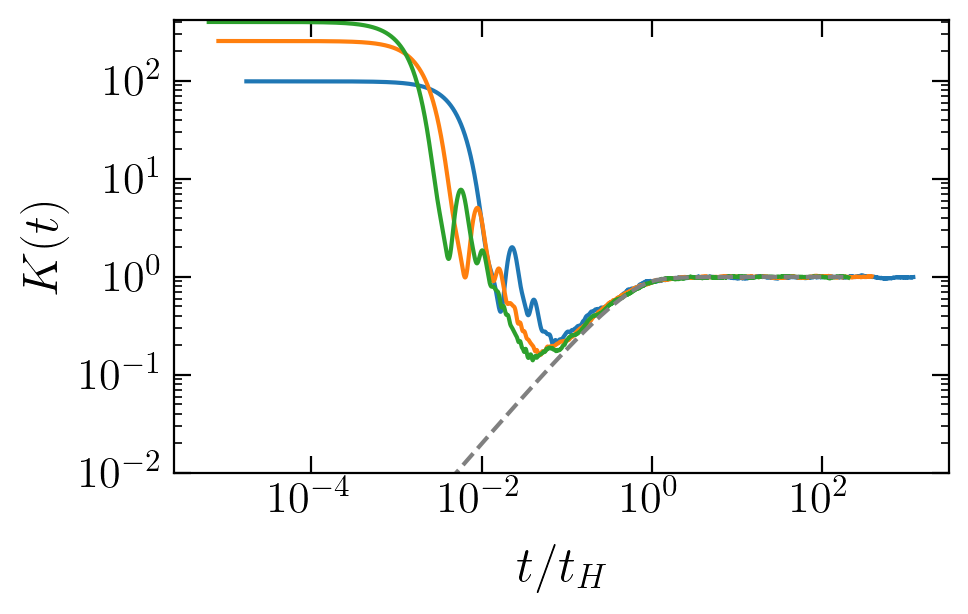

In [356]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

L = 400
tau = 1
mass = 2
BC = 0 #PBC: BC=1


fig_K, axis_K = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200, sharex=True)

# axis2 = axis.twinx()

timesX = np.logspace(-2, 6, 5000)
sizes = [100, 256, 400]
for L in sizes:
    arr = [tau, mass]
    names = ['tau', 'm']
    infoLieb = "_L=%d"%(L)
    for i, var in enumerate(arr):
        # print(names[i], var)
        n = order_of_magnitude( np.abs(var) )
        if np.abs(var) < 1e-15:
            infoLieb += str(",%s=0"%(names[i]))
        elif var < 0:
            infoLieb += str(",%s=-{:.%df}"%(names[i], n)).format(round(np.abs(var), n))     
        else:
            infoLieb += str(",%s={:.%df}"%(names[i], n)).format(round(np.abs(var), n))

    counter = 0
    tH = 0
    sff = np.zeros(timesX.shape)
    for r in range(50):
        name = "../results/LiebLatticeRandomShape/realization=%d/"%r + infoLieb + ".hdf5"
        if exists(name):
            with h5py.File(name, "r") as file:
                E = np.array(file.get('E'))[0]
                # print(E.size)
                E = np.round(E, 14)
                _, indices, counts = np.unique(E, return_index=True, return_counts=True)
                non_deg_idx = []
                for new_iii, idx in enumerate(indices):
                    if counts[new_iii] == 1:
                        non_deg_idx.append(idx)
                E = E[ non_deg_idx ]
                E = E[E < -1e-10]
                # E = E[np.abs(E) >= 4*mass]
                
                tH += 2*np.pi / np.mean(np.diff(E))
                
                sff += np.abs(np.exp(1j * np.outer(E, timesX)).sum(axis=0))**2
                counter += 1
        else:
            print(name)
    tH = tH / counter
    sff = sff / counter
    sff = tools.remove_fluctuations(sff, bucket_size=100)[50 :-50]; timesX = timesX[50 : -50]
    axis_K.plot(timesX / tH, sff / E.size, ls='-')
    # axis_K.plot(timesX / np.sqrt(L), sff / E.size, ls='-')

axis_K.plot(timesX / tH, goe.spectral_form_factor(timesX / tH), ls='--', color='gray')
axis_K.set_ylim(1e-2, None)        

fig_help.set_plot_elements(axis_K, ylabel=r"$K(t)$", xlabel=r"$t/t_H$", font_size=16, set_legend=1, xscale='log', yscale='log')

fig.subplots_adjust(wspace = 0.02, hspace=0.02)

Dimer band 0.5295925181102494
Monomer bands 0.5305246004966864
Dimer band 0.8596771076055612
Monomer bands 0.6990486873491176


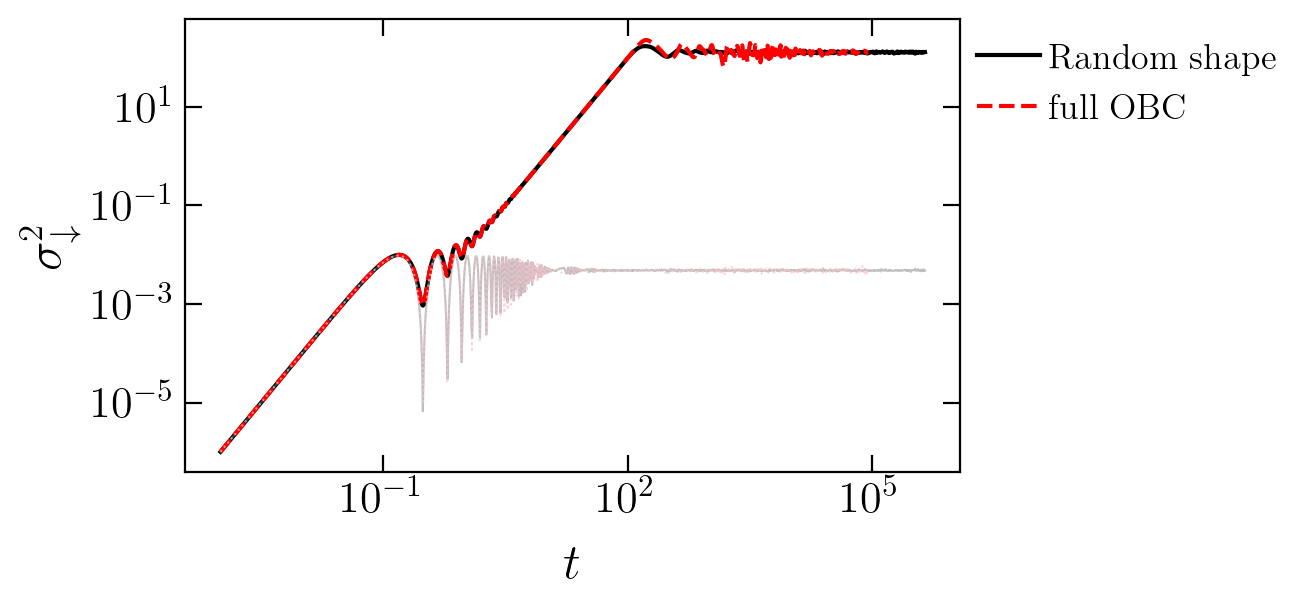

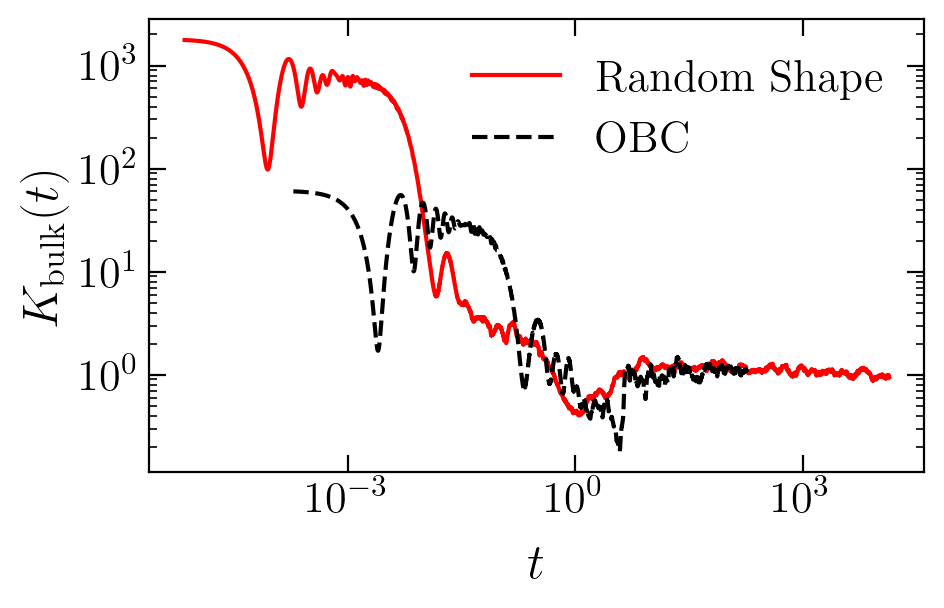

In [311]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

Lx = 30
Ly = 30
Nu = -1
Nd = 1
L = Lx*Ly
tau = 1
mass = 5
BC = 0 #PBC: BC=1


fig, axis = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200, sharex=True)
fig_K, axis_K = plt.subplots( nrows=1, ncols=1, figsize=(5,3), dpi = 200, sharex=True)


arr = [tau, mass]
names = ['tau', 'm']
infoLieb = "_L=%d"%(L)
for i, var in enumerate(arr):
    # print(names[i], var)
    n = order_of_magnitude( np.abs(var) )
    if np.abs(var) < 1e-15:
        infoLieb += str(",%s=0"%(names[i]))
    elif var < 0:
        infoLieb += str(",%s=-{:.%df}"%(names[i], n)).format(round(np.abs(var), n))     
    else:
        infoLieb += str(",%s={:.%df}"%(names[i], n)).format(round(np.abs(var), n))

name = "../results/LiebLatticeRandomShape/realization=0/" + infoLieb + ".hdf5"
if exists(name):
    with h5py.File(name, "r") as file:
        times = np.array(file.get('times'))[0,1:]
        Ndimer = 1 - np.array(file.get('SpinDownNumber(t)'))[0,1:]
        sigma = (np.array(file.get('spreading'))[0,1:])
        # SpinDown = np.array(file.get('Autocorrelation_spindown'))[0,1:]
        
        axis.plot(times / 1, sigma, color='k', lw=1.5, label = r"Random shape")
        axis.plot(times, Ndimer/4, color='gray', lw=0.75, ls = '-', alpha = 0.5)
        
        E = np.array(file.get('E'))[0]
        E = np.round(E, 12)
        _, indices, counts = np.unique(E, return_index=True, return_counts=True)
        non_deg_idx = []
        for new_iii, idx in enumerate(indices):
            if counts[new_iii] == 1:
                non_deg_idx.append(idx)
        E = E[ non_deg_idx ]
        E = E[np.abs(E) > 1e-10]
        
        timesX = np.logspace(-2, np.log(E.size), 5000)
        sff = np.abs(np.exp(1j * np.outer(E, timesX)).sum(axis=0))**2
        sff = tools.remove_fluctuations(sff, bucket_size=100)[50 :-50]; timesX = timesX[50 : -50]
        axis_K.plot(timesX/ E.size, sff / E.size, color='red', ls='-', label = r"Random Shape")
        
        Eband = E[E < -1e-10]
        gaps = np.diff(Eband)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        print("Dimer band", np.mean(ratio_tmp))
        
        Eband = E[np.abs(E) >= 4 * mass]
        if Eband.size > 2:
            gaps = np.diff(Eband)
            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            print("Monomer bands", np.mean(ratio_tmp))
else:
    print(name)
name = base_dir(BC) + "SpinImpurity/" + info(Lx, Ly, Nu, Nd, tau, mass)
if exists(name):
    with h5py.File(name, "r") as file:
        times = np.array(file.get('times'))[0,1:]
        Ndimer = np.array(file.get('DimerNumber(t)'))[0,1:]
        sigma = (np.array(file.get('spreading'))[0,1:])
        # SpinDown = np.array(file.get('Autocorrelation_spindown'))[0,1:]
        
        axis.plot(times / 1, sigma, color='red', lw=1.5, ls='--', label = r"full OBC")
        
        axis.plot(times, Ndimer/4, color='pink', lw=0.75, ls = ':', alpha = 0.7)
        
        E = np.array(file.get('energies'))[0]
        E = np.round(E, 12)
        _, indices, counts = np.unique(E, return_index=True, return_counts=True)
        non_deg_idx = []
        for new_iii, idx in enumerate(indices):
            if counts[new_iii] == 1:
                non_deg_idx.append(idx)
        E = E[ non_deg_idx ]
        E = E[np.abs(E) > 1e-10]
        # print(E)
        
        timesX = np.logspace(-2, np.log(E.size), 5000)
        sff = np.abs(np.exp(1j * np.outer(E, timesX)).sum(axis=0))**2
        sff = tools.remove_fluctuations(sff, bucket_size=100)[50 :-50]; timesX = timesX[50 : -50]
        axis_K.plot(timesX/ E.size, sff / E.size, color='k', ls='--', label = r"OBC")
        
        Eband = E[E < -1e-10]
        gaps = np.diff(Eband)
        ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
        print("Dimer band", np.mean(ratio_tmp))
        
        Eband = E[np.abs(E) >= 4 * mass]
        if Eband.size > 2:
            gaps = np.diff(Eband)
            ratio_tmp = np.minimum(gaps[:-1], gaps[1:]) / np.maximum(gaps[:-1], gaps[1:])
            print("Monomer bands", np.mean(ratio_tmp))
else:
    print(name)
fig_help.set_plot_elements(axis, ylabel=r"$\sigma_{\downarrow}^2$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
fig_help.set_legend(axis, fontsize=13, loc='upper left', anchor=(0.98, 1.02))

fig_help.set_plot_elements(axis_K, ylabel=r"$K_{\rm bulk}(t)$", xlabel=r"$t$", font_size=16, set_legend=1, xscale='log', yscale='log')
